[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pachterlab/OP_2025/blob/main/analysis_scripts/Virus_DEseq.ipynb)

# Clone github repo

In [1]:
!git clone https://github.com/pachterlab/OP_2025.git
%cd /content/OP_2025/

Cloning into 'OP_2025'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 238 (delta 9), reused 17 (delta 5), pack-reused 211 (from 1)
Receiving objects: 100% (238/238), 29.59 MiB | 13.85 MiB/s, done.
Resolving deltas: 100% (95/95), done.
/content/OP_2025


# Download Data

# Install Packages

In [3]:
!pip install -qr requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 459.2/459.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.1/821.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.0 MB/s eta 0:00:00
   ━━━━

In [1]:
# import packages

import os, sys
sys.path.append('analysis_scripts')
from pathlib import Path

import time

# numbers
import numpy as np
import pandas as pd

# sc
import anndata
import scanpy as sc

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import statsmodels.stats.multitest

# plots
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

# for blast
from pycirclize import Circos
from Bio import SeqIO
from tqdm import tqdm
import random

from rat_friend import *

In [ ]:
color_opts =  np.array([
    "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#E69F00", "#CC79A7", "#666666", "#AD7700", "#1C91D4", "#007756", "#D5C711", "#005685",
    "#A04700", "#B14380", "#4D4D4D", "#FFBE2D", "#80C7EF", "#00F6B3", "#F4EB71", "#06A5FF", "#FF8320", "#D99BBD", "#8C8C8C", "#FFCB57", "#9AD2F2",
    "#2CFFC6", "#F6EF8E", "#38B7FF", "#FF9B4D", "#E0AFCA", "#A3A3A3", "#8A5F00", "#1674A9", "#005F45", "#AA9F0D", "#00446B", "#803800", "#8D3666",
    "#3D3D3D"
])
tissues = ['ADRNL','BAT','BLOOD','COLON','CORTEX','HEART','HIPPOC','HYPOTH',
 'KIDNEY','LIVER', 'LUNG','OVARY','SKM-GN','SKM-VL','SMLINT','SPLEEN','TESTES','VENACV','WAT']
color_dict = {}

for x in range(len(tissues)):
    color_dict[tissues[x]] = color_opts[x]

color_dict

# Get BLAST results

In [5]:
# Download BLAST+ Linux binary
!wget https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/2.14.1/ncbi-blast-2.14.1+-x64-linux.tar.gz
!tar -xvf ncbi-blast-2.14.1+-x64-linux.tar.gz

--2025-08-04 13:36:23--  https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/2.14.1/ncbi-blast-2.14.1+-x64-linux.tar.gz
130.14.250.11, 130.14.250.10, 130.14.250.13, ....gov)... 
connected. to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.11|:443... 
HTTP request sent, awaiting response... 200 OK
Length: 251154151 (240M) [application/x-gzip]
Saving to: ‘ncbi-blast-2.14.1+-x64-linux.tar.gz’

ncbi-blast-2.14.1+- 100%[===================>] 239.52M  23.8MB/s    in 11s     

2025-08-04 13:36:34 (21.4 MB/s) - ‘ncbi-blast-2.14.1+-x64-linux.tar.gz’ saved [251154151/251154151]

ncbi-blast-2.14.1+/
ncbi-blast-2.14.1+/README
ncbi-blast-2.14.1+/doc/
ncbi-blast-2.14.1+/doc/README.txt
ncbi-blast-2.14.1+/BLAST_PRIVACY
ncbi-blast-2.14.1+/ChangeLog
ncbi-blast-2.14.1+/bin/
ncbi-blast-2.14.1+/bin/tblastx
ncbi-blast-2.14.1+/bin/blast_formatter_vdb
ncbi-blast-2.14.1+/bin/blastp
ncbi-blast-2.14.1+/bin/blastdbcmd
ncbi-blast-2.14.1+/bin/makeprofiledb
ncbi-blast-2.14.1+/bin/makeblastdb
ncbi-blast-2.1

In [7]:
# Path to foler with BLAST+ binaries
blast_bins = "/home/coakes/rat/ncbi-blast-2.14.1+/bin"
# Define path to store BLAST+ databases
BLASTDB="/home/coakes/rat/ncbi-blast-2.14.1+/dbs"
!mkdir $BLASTDB

In [46]:
# Download BLAST nt database
!cd $BLASTDB && $blast_bins/update_blastdb.pl --decompress nt

ERROR: Need 730165770760 bytes and only 100908498944 bytes are available


In [2]:
virs_to_blast = ['u234187']
srrs = ['SRR25251828', 'SRR25251318']

In [40]:
!cd $BLASTDB && \
                            $blast_bins/blastn \
                            -task blastn \
                            -db $blast_database \
                            -query /home/coakes/rat/$tmp_fasta \
                            -outfmt "7 delim=, staxid ssciname scomname sskingdom qseq sseq length evalue score bitscore pident qcovs gaps" \
                            -num_threads $threads \
                            -max_target_seqs $max_target_seqs \
                            -out $tmp_out

BLAST Database error: No alias or index file found for nucleotide database [nt] in search path [/home/coakes/rat/ncbi-blast-2.14.1+/dbs::]


In [37]:
%%time
# Max number of sequences to blast per virus (randomly chosen from fasta/fastq)
read_nums_blast = 10
# Max number of BLAST hits to keep per read
max_target_seqs = 20

threads = 8

TQDM_BAR_FORMAT2 = (
    "{l_bar}{bar}| {n_fmt}/{total_fmt} reads blasted [elapsed: {elapsed} remaining: {remaining}]"
)

tmp_out = "temp.csv"
tmp_fasta = "temp.fa"
blast_database = "nt"

master_df = pd.DataFrame()
for virus_id in virs_to_blast:
    vir_df = pd.DataFrame()
    for srr in srrs:
        # Get sequences from fastq
        fasta_file = f"virus_fastqs/{srr}_extracted_{virus_id}.fastq"

        try:
            # print(f"Getting reads for {virus_id} from {srr}...")
            seqs = []
            with open(fasta_file, "rt") as handle:
                for record in SeqIO.parse(handle, "fastq"):
                    seqs.append(record.seq)

            if len(seqs) > 0:
                # BLAST sequences individually and store top [max_target_seqs] hits
                with tqdm(total=read_nums_blast, bar_format=TQDM_BAR_FORMAT2) as pbar:
                    pbar.set_description(srr + " " + virus_id)

                    for i, seq in enumerate(random.choices(seqs, k=read_nums_blast)):
                        # # BLAST with gget
                        # df_temp = gget.blast(seq, limit=20, verbose=False)
                        # BLAST with BLAST+
                        with open(tmp_fasta, "w") as tmpfa:
                            tmpfa.write(">\n" + str(seq))
                        print(os.getcwd())
                        !cd $BLASTDB && \
                            $blast_bins/blastn \
                            -task blastn \
                            -db $blast_database \
                            -query $tmp_fasta \
                            -outfmt "7 delim=, staxid ssciname scomname sskingdom qseq sseq length evalue score bitscore pident qcovs gaps" \
                            -num_threads $threads \
                            -max_target_seqs $max_target_seqs \
                            -out $tmp_out

                        header_list = [
                            "Subject Taxonomy ID",
                            "Subject Scientific Name",
                            "Subject Common Name",
                            "Subject Super Kingdom",
                            "Aligned part of query sequence",
                            "Aligned part of subject sequence",
                            "Alignment length",
                            "Expect value",
                            "Raw score",
                            "Bit score",
                            "Percentage of identical matches",
                            "Query Coverage Per Subject",
                            "Total number of gaps",
                        ]

                        df_temp = pd.read_csv(tmp_out, skiprows=5, names=header_list, header=None)
                        # Remove last row (comment line)
                        df_temp = df_temp[:-1]

                        # print(len(df_temp))
                        if len(df_temp) > 0:
                            df_temp["read"] = i
                            df_temp["srr"] = srr

                            vir_df = pd.concat([vir_df, df_temp])

                        else:
                            print(f"No BLAST hits found for {virus_id} read {i} from library {srr}.")

                        pbar.update(n=1)

            else:
                print(f"No aligned sequences found for {virus_id} in library {srr}.")
                continue

        except FileNotFoundError:
            print(f"FileNotFoundError: {fasta_file}")
            continue

    if len(vir_df) > 0:
        vir_df["virus"] = virus_id
        master_df = pd.concat([master_df, vir_df])
        
master_df.to_csv(f"pull_out_reads_blast+_{blast_database}.csv", index=False)

SRR25251828 u234187:   0%|    | 0/10 reads blasted [elapsed: 00:00 remaining: ?]

/home/coakes/rat
Command line argument error: Argument "query". File is not accessible:  `temp.fa'



RR25251828 u234187:   0%|    | 0/10 reads blasted [elapsed: 00:00 remaining: ?]

FileNotFoundError: virus_fastqs/SRR25251828_extracted_u234187.fastq


SRR25251318 u234187:   0%|    | 0/10 reads blasted [elapsed: 00:00 remaining: ?]

/home/coakes/rat
Command line argument error: Argument "query". File is not accessible:  `temp.fa'


SRR25251318 u234187:   0%|    | 0/10 reads blasted [elapsed: 00:00 remaining: ?]

FileNotFoundError: virus_fastqs/SRR25251318_extracted_u234187.fastq
CPU times: user 29.5 ms, sys: 53.8 ms, total: 83.3 ms
Wall time: 1.05 s


In [3]:
blast_database = "nt"
master_df = pd.read_csv(f"pull_out_reads_blast+_{blast_database}.csv")
master_df.head()

,Subject Taxonomy ID,Subject Scientific Name,Subject Common Name,Subject Super Kingdom,Aligned part of query sequence,Aligned part of subject sequence,Alignment length,Expect value,Raw score,Bit score,Percentage of identical matches,Query Coverage Per Subject,Total number of gaps,read,srr,virus
0,10258,Orf virus,Orf virus,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACGCAAGATC---...,99.0,8.500000e-24,137.0,124.0,87.879,100.0,9.0,0,SRR25251828,u234187
1,10258,Orf virus,Orf virus,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGA,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACGCAAGA,41.0,1.000000e-03,63.0,58.1,92.683,100.0,1.0,0,SRR25251828,u234187
2,4579,Zea mays subsp. mexicana,Zea mays subsp. mexicana,Eukaryota,CACGAGAACCAATACTTATCTCGTATGCCGTCTTCTGCTTGAAAAG...,CACGAGACTCAGTGCTTATCTCGTATGCCGTCTTCTGCTTGAAAAG...,65.0,9.700000e-17,110.0,100.0,93.846,66.0,0.0,0,SRR25251828,u234187
3,2697049,Severe acute respiratory syndrome coronavirus 2,Severe acute respiratory syndrome coronavirus 2,Viruses,GATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAAT...,GATCGGAAGAGC-ACACGTCTGAACTCCAGTCACAGG----CC--T...,78.0,1.440000e-14,103.0,94.2,88.462,79.0,7.0,0,SRR25251828,u234187
4,511145,Escherichia coli str. K-12 substr. MG1655,Escherichia coli str. K-12 substr. MG1655,Bacteria,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACAC-AGAACGA-...,79.0,1.440000e-14,102.0,93.3,87.342,80.0,9.0,0,SRR25251828,u234187


In [4]:
# Remove polyA/T alignments since these are resutls from raw reads
master_df = master_df[
    ~(master_df["Aligned part of subject sequence"].str.contains("TTTTTTTTTTTT"))
    & ~(master_df["Aligned part of query sequence"].str.contains("TTTTTTTTTTTT"))
    & ~(master_df["Aligned part of subject sequence"].str.contains("AAAAAAAAAAAA"))
    & ~(master_df["Aligned part of query sequence"].str.contains("AAAAAAAAAAAA"))
]

# Categorize SRRs as int
master_df["srr_num"] = pd.factorize(master_df.srr)[0]

# Add new "read" column that includes srr number as well as read number
master_df["read"] = (
    master_df["srr_num"].astype(str) + "." + master_df["read"].astype(str)
)

# Save cleaned up df
master_df.to_csv(f"pull_out_reads_blast+_{blast_database}_clean.csv", index=False)

master_df

,Subject Taxonomy ID,Subject Scientific Name,Subject Common Name,Subject Super Kingdom,Aligned part of query sequence,Aligned part of subject sequence,Alignment length,Expect value,Raw score,Bit score,Percentage of identical matches,Query Coverage Per Subject,Total number of gaps,read,srr,virus,srr_num
0,10258,Orf virus,Orf virus,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACGCAAGATC---...,99.0,8.500000e-24,137.0,124.0,87.879,100.0,9.0,0.0,SRR25251828,u234187,0
1,10258,Orf virus,Orf virus,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGA,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACGCAAGA,41.0,1.000000e-03,63.0,58.1,92.683,100.0,1.0,0.0,SRR25251828,u234187,0
2,4579,Zea mays subsp. mexicana,Zea mays subsp. mexicana,Eukaryota,CACGAGAACCAATACTTATCTCGTATGCCGTCTTCTGCTTGAAAAG...,CACGAGACTCAGTGCTTATCTCGTATGCCGTCTTCTGCTTGAAAAG...,65.0,9.700000e-17,110.0,100.0,93.846,66.0,0.0,0.0,SRR25251828,u234187,0
3,2697049,Severe acute respiratory syndrome coronavirus 2,Severe acute respiratory syndrome coronavirus 2,Viruses,GATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAAT...,GATCGGAAGAGC-ACACGTCTGAACTCCAGTCACAGG----CC--T...,78.0,1.440000e-14,103.0,94.2,88.462,79.0,7.0,0.0,SRR25251828,u234187,0
4,511145,Escherichia coli str. K-12 substr. MG1655,Escherichia coli str. K-12 substr. MG1655,Bacteria,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACAC-AGAACGA-...,79.0,1.440000e-14,102.0,93.3,87.342,80.0,9.0,0.0,SRR25251828,u234187,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,10386,Gallid alphaherpesvirus 1,Gallid alphaherpesvirus 1,Viruses,ATCTCGTATGCCGTCTTCTGCTTGAAAAGGGGGGGGGGGGGGGGGGGG,ATCTCGTATGCCGTCTTCTGCTTGAAAAGGGGGGGGGGGGGGGGGGGG,48.0,6.120000e-13,96.0,87.8,100.000,48.0,0.0,4.9,SRR25251613,u234187,4
1296,2697049,Severe acute respiratory syndrome coronavirus 2,Severe acute respiratory syndrome coronavirus 2,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGA-GAACCA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCAC--GACGAAC--...,80.0,6.120000e-13,96.0,87.8,86.250,80.0,11.0,4.9,SRR25251613,u234187,4
1297,2697049,Severe acute respiratory syndrome coronavirus 2,Severe acute respiratory syndrome coronavirus 2,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACTCAAGGAT---...,79.0,2.140000e-12,95.0,86.9,84.810,80.0,7.0,4.9,SRR25251613,u234187,4
1298,2697049,Severe acute respiratory syndrome coronavirus 2,Severe acute respiratory syndrome coronavirus 2,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCAC-ACGAGAACCA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACCACTAGG----...,80.0,2.140000e-12,94.0,86.0,86.250,80.0,9.0,4.9,SRR25251613,u234187,4


/tmp/ipykernel_2506339/3602117388.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  matplotlib.cm.get_cmap("BrBG")


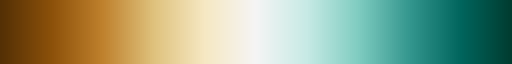

In [20]:
matplotlib.cm.get_cmap("BrBG")

In [55]:
def plot_blast_results(master_df, virs_to_plot, tax_level="Subject Super Kingdom", ref = 'Viruses', read_nums = 10,
                      save_name = 'plot.png'):

    if type(virs_to_plot) == str:
        virs_to_plot = [virs_to_plot]

    sectors = {}

    # Sector sizes in plot
    orig_seq_size = 5
    blast_hit_size = 5

    # Define read sectors
    for virus_id in virs_to_plot:
        vir_df = master_df[master_df["virus"] == virus_id]

        for read in vir_df["read"].unique()[:read_nums]:
            sectors[f"{virus_id}\n{read}"] = orig_seq_size

    # Define BLAST result sectors
    matches_per_read = {}
    for virus_id in virs_to_plot:
        vir_df = master_df[master_df["virus"] == virus_id]

        for read in vir_df["read"].unique()[:read_nums]:
            df = vir_df[vir_df["read"]==read]

            query_cover_fracs = []
            per_idents = []
            blast_hits = []

            if tax_level == "Subject Super Kingdom":
                # Define order of superkingdoms
                taxlevels = ["Eukaryota", "Bacteria", "Archaea", "Viruses"]
            else:
                taxlevels = df[tax_level].unique()

            for species in taxlevels:
                if len(df[df[tax_level]==species]) > 0:
                    try:
                        sectors[species.replace(" ", "\n")] = blast_hit_size
                        blast_hits.append(species.replace(" ", "\n"))

                        # Get values for the top hit for each taxlevel
                        query_cover_fracs.append(df[df[tax_level]==species]["Query Coverage Per Subject"].values[0]/100)
                        per_idents.append(df[df[tax_level]==species]["Percentage of identical matches"].values[0])

                        matches_per_read[f"{virus_id} {read}"] = {
                            "query_cover_fracs": query_cover_fracs,
                            "per_idents": per_idents,
                            "blast_hits": blast_hits
                        }

                    # If Scientific Name is NaN, skip this hit
                    except AttributeError:
                        continue

    filtered_sectors = {}
    for x in sectors.keys():
        if (x == ref) or ('u' in x and '.' in x):
            filtered_sectors[x] = sectors[x]
    sectors = filtered_sectors
    # Create plot
    circos = Circos(sectors, space=2)
    fontsize = 9
    coverage_label = False

    read_idx = 1
    for sector in circos.sectors:
        track = sector.add_track((90, 100))

        if "u" in sector.name and "." in sector.name:
            track.axis(fc="lightgrey")

            # track.text(sector.name, color="black", size=fontsize) # Add virus ID to grey read sectors
            track.text(f"Read {read_idx}", color="black", size=fontsize) # Just add "Read X" to the grey read sectors
            read_idx += 1

            # track.xticks(np.arange(orig_seq_size+1), np.linspace(0, 100, orig_seq_size+1).astype(int), label_size=fontsize)
            track.xticks([0, 2.5, 5], np.linspace(0, 100, 3).astype(int), label_size=fontsize-2)
            if not coverage_label:
                track.text("     Coverage (%)", color="black", size=fontsize+4, r=110)
                coverage_label = True
        elif ref in sector.name:
            if "Eukaryota" in sector.name:
                track.axis(fc="red")
                track.text(sector.name, color="white", size=fontsize-1)
    
            elif "Viruses" in sector.name:
                track.axis(fc="green")
                track.text(sector.name, color="black", size=fontsize)
    
            elif "Bacteria" in sector.name:
                track.axis(fc="blue")
                track.text(sector.name, color="black", size=fontsize)
    
            elif "Archaea" in sector.name:
                track.axis(fc="grey")
                track.text(sector.name, color="white", size=fontsize)
        else:
            track.axis(fc="black")
            track.text(sector.name, color="white", size=fontsize)

    # Define colormap
    cmap = matplotlib.cm.get_cmap("Blues")
    norm = matplotlib.colors.Normalize(vmin=80, vmax=100) # Define min and max of colorbar

    # Plot links
    for virus_id in virs_to_plot:
        for read in master_df[master_df["virus"]==virus_id]["read"].unique()[:read_nums]:

            per_idents = matches_per_read[f"{virus_id} {read}"]["per_idents"]
            query_cover_fracs = matches_per_read[f"{virus_id} {read}"]["query_cover_fracs"]
            blast_hits = matches_per_read[f"{virus_id} {read}"]["blast_hits"]

            for iden, qc_frac, blast_hit in zip(per_idents, query_cover_fracs, blast_hits):
                if blast_hit == ref: 
                    if blast_hit == 'Eukaryota':
                        cmap = matplotlib.cm.get_cmap("Reds")
                    elif blast_hit == 'Viruses':
                        cmap = matplotlib.cm.get_cmap("Greens")
                    elif blast_hit == 'Bacteria':
                        cmap = matplotlib.cm.get_cmap("Blues")
                    else:
                        cmap = matplotlib.cm.get_cmap("BrBG")
                        
                    circos.link((f"{virus_id}\n{read}", 0, orig_seq_size*qc_frac), (blast_hit, blast_hit_size, 0), color=cmap(norm(iden)))

    fig = circos.plotfig(figsize = (16, 16))
    fig.savefig(save_name, dpi=300, bbox_inches="tight")

    # Add horizontal colorbar
    fig, ax = plt.subplots(figsize=(6, 1))
    fig.subplots_adjust(bottom=0.5)
    cb1 = matplotlib.colorbar.ColorbarBase(
        ax,
        cmap=cmap,
        norm=norm,
        orientation='horizontal'
    )
    cb1.set_label('Identity (%)', size=fontsize*2)

      # Add vertical colorbar
#     fig, ax = plt.subplots(figsize=(0.5, 12))
#     fig.subplots_adjust(bottom=0.5)
#     cb1 = matplotlib.colorbar.ColorbarBase(
#         ax,
#         cmap=cmap,
#         norm=norm,
#         orientation='vertical'
#     )
#     cb1.set_label('Identity (%)', size=fontsize*2)
#     ticklabs = cb1.ax.get_yticklabels()
#     cb1.ax.set_yticklabels(ticklabs, fontsize=fontsize*2-2)

    #fig.savefig("figures_final/supp_fig_12b.png", dpi=300, bbox_inches="tight")

    fig.show()

In [56]:
tax_df = pd.read_csv('detailed_tax.tsv', sep='\t', header=None)
tax_df[['domain|acellular root|superkingdom','phylum','class','order','family','genus','species','strain|subspecies|no rank']] = tax_df[1].str.split(';',expand=True)
tax_df.rename(columns={0: 'Subject Taxonomy ID'}, inplace=True)
tax_df.head()

,Subject Taxonomy ID,1,domain|acellular root|superkingdom,phylum,class,order,family,genus,species,strain|subspecies|no rank
0,10258,Viruses;Nucleocytoviricota;Pokkesviricetes;Chi...,Viruses,Nucleocytoviricota,Pokkesviricetes,Chitovirales,Poxviridae,Parapoxvirus,Parapoxvirus orf,Orf virus
1,2697049,Viruses;Pisuviricota;Pisoniviricetes;Nidoviral...,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Betacoronavirus pandemicum,Severe acute respiratory syndrome coronavirus 2
2,511145,Bacteria;Pseudomonadota;Gammaproteobacteria;En...,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,Escherichia coli,Escherichia coli K-12
3,10386,Viruses;Peploviricota;Herviviricetes;Herpesvir...,Viruses,Peploviricota,Herviviricetes,Herpesvirales,Orthoherpesviridae,Iltovirus,Iltovirus gallidalpha1,Gallid alphaherpesvirus 1
4,1352,Bacteria;Bacillota;Bacilli;Lactobacillales;Ent...,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecium,


In [57]:
final_df = pd.merge(master_df, tax_df, on= 'Subject Taxonomy ID', how = 'left')
final_df[final_df==""] = np.nan
final_df = final_df.fillna(method='ffill',axis=1)
final_df.head()

,Subject Taxonomy ID,Subject Scientific Name,Subject Common Name,Subject Super Kingdom,Aligned part of query sequence,Aligned part of subject sequence,Alignment length,Expect value,Raw score,Bit score,...,srr_num,1,domain|acellular root|superkingdom,phylum,class,order,family,genus,species,strain|subspecies|no rank
0,10258,Orf virus,Orf virus,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACGCAAGATC---...,99.0,0.0,137.0,124.0,...,0,Viruses;Nucleocytoviricota;Pokkesviricetes;Chi...,Viruses,Nucleocytoviricota,Pokkesviricetes,Chitovirales,Poxviridae,Parapoxvirus,Parapoxvirus orf,Orf virus
1,10258,Orf virus,Orf virus,Viruses,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGA,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACGCAAGA,41.0,0.001,63.0,58.1,...,0,Viruses;Nucleocytoviricota;Pokkesviricetes;Chi...,Viruses,Nucleocytoviricota,Pokkesviricetes,Chitovirales,Poxviridae,Parapoxvirus,Parapoxvirus orf,Orf virus
2,4579,Zea mays subsp. mexicana,Zea mays subsp. mexicana,Eukaryota,CACGAGAACCAATACTTATCTCGTATGCCGTCTTCTGCTTGAAAAG...,CACGAGACTCAGTGCTTATCTCGTATGCCGTCTTCTGCTTGAAAAG...,65.0,0.0,110.0,100.0,...,0,Eukaryota;Streptophyta;Magnoliopsida;Poales;Po...,Eukaryota,Streptophyta,Magnoliopsida,Poales,Poaceae,Zea,Zea mays,Zea mays subsp. mexicana
3,2697049,Severe acute respiratory syndrome coronavirus 2,Severe acute respiratory syndrome coronavirus 2,Viruses,GATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAAT...,GATCGGAAGAGC-ACACGTCTGAACTCCAGTCACAGG----CC--T...,78.0,0.0,103.0,94.2,...,0,Viruses;Pisuviricota;Pisoniviricetes;Nidoviral...,Viruses,Pisuviricota,Pisoniviricetes,Nidovirales,Coronaviridae,Betacoronavirus,Betacoronavirus pandemicum,Severe acute respiratory syndrome coronavirus 2
4,511145,Escherichia coli str. K-12 substr. MG1655,Escherichia coli str. K-12 substr. MG1655,Bacteria,AGATCGGAAGAGCCACACGTCTGAACTCCAGTCACACGAGAACCAA...,AGATCGGAAGAGC-ACACGTCTGAACTCCAGTCACAC-AGAACGA-...,79.0,0.0,102.0,93.3,...,0,Bacteria;Pseudomonadota;Gammaproteobacteria;En...,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Escherichia,Escherichia coli,Escherichia coli K-12


/tmp/ipykernel_2506339/1472499993.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Blues")
/tmp/ipykernel_2506339/1472499993.py:123: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Blues")
/tmp/ipykernel_2506339/1472499993.py:121: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("Greens")
/tmp/ipykernel_2506339/1472499993.py:119: MatplotlibDeprecationWarning: The get_cmap

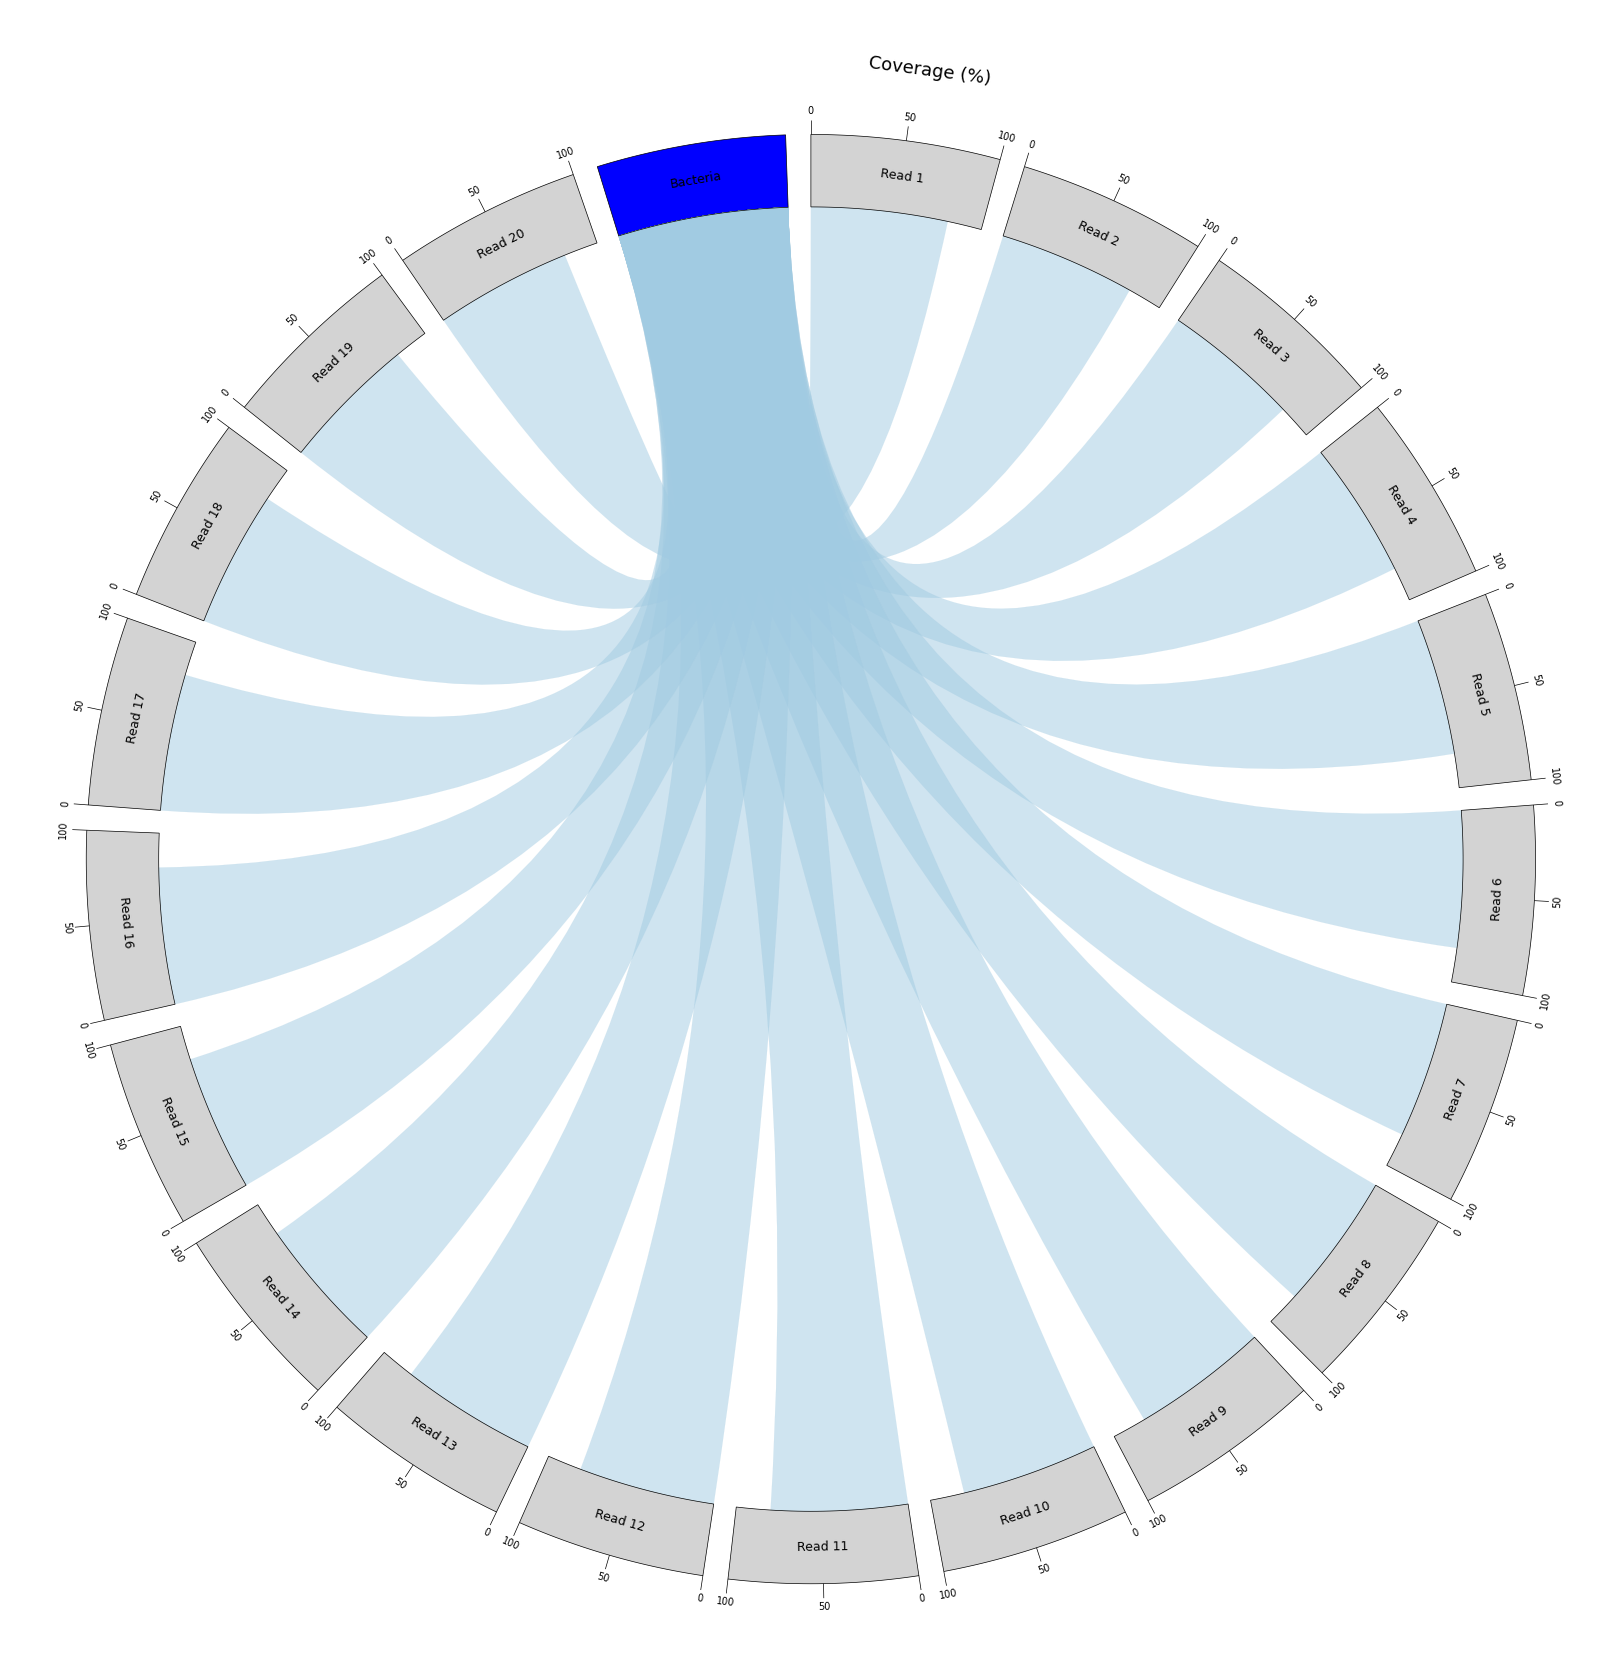

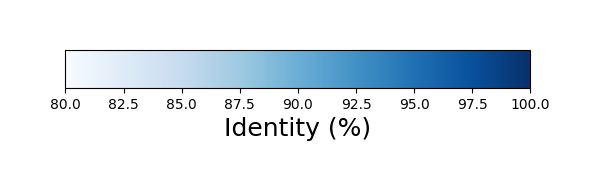

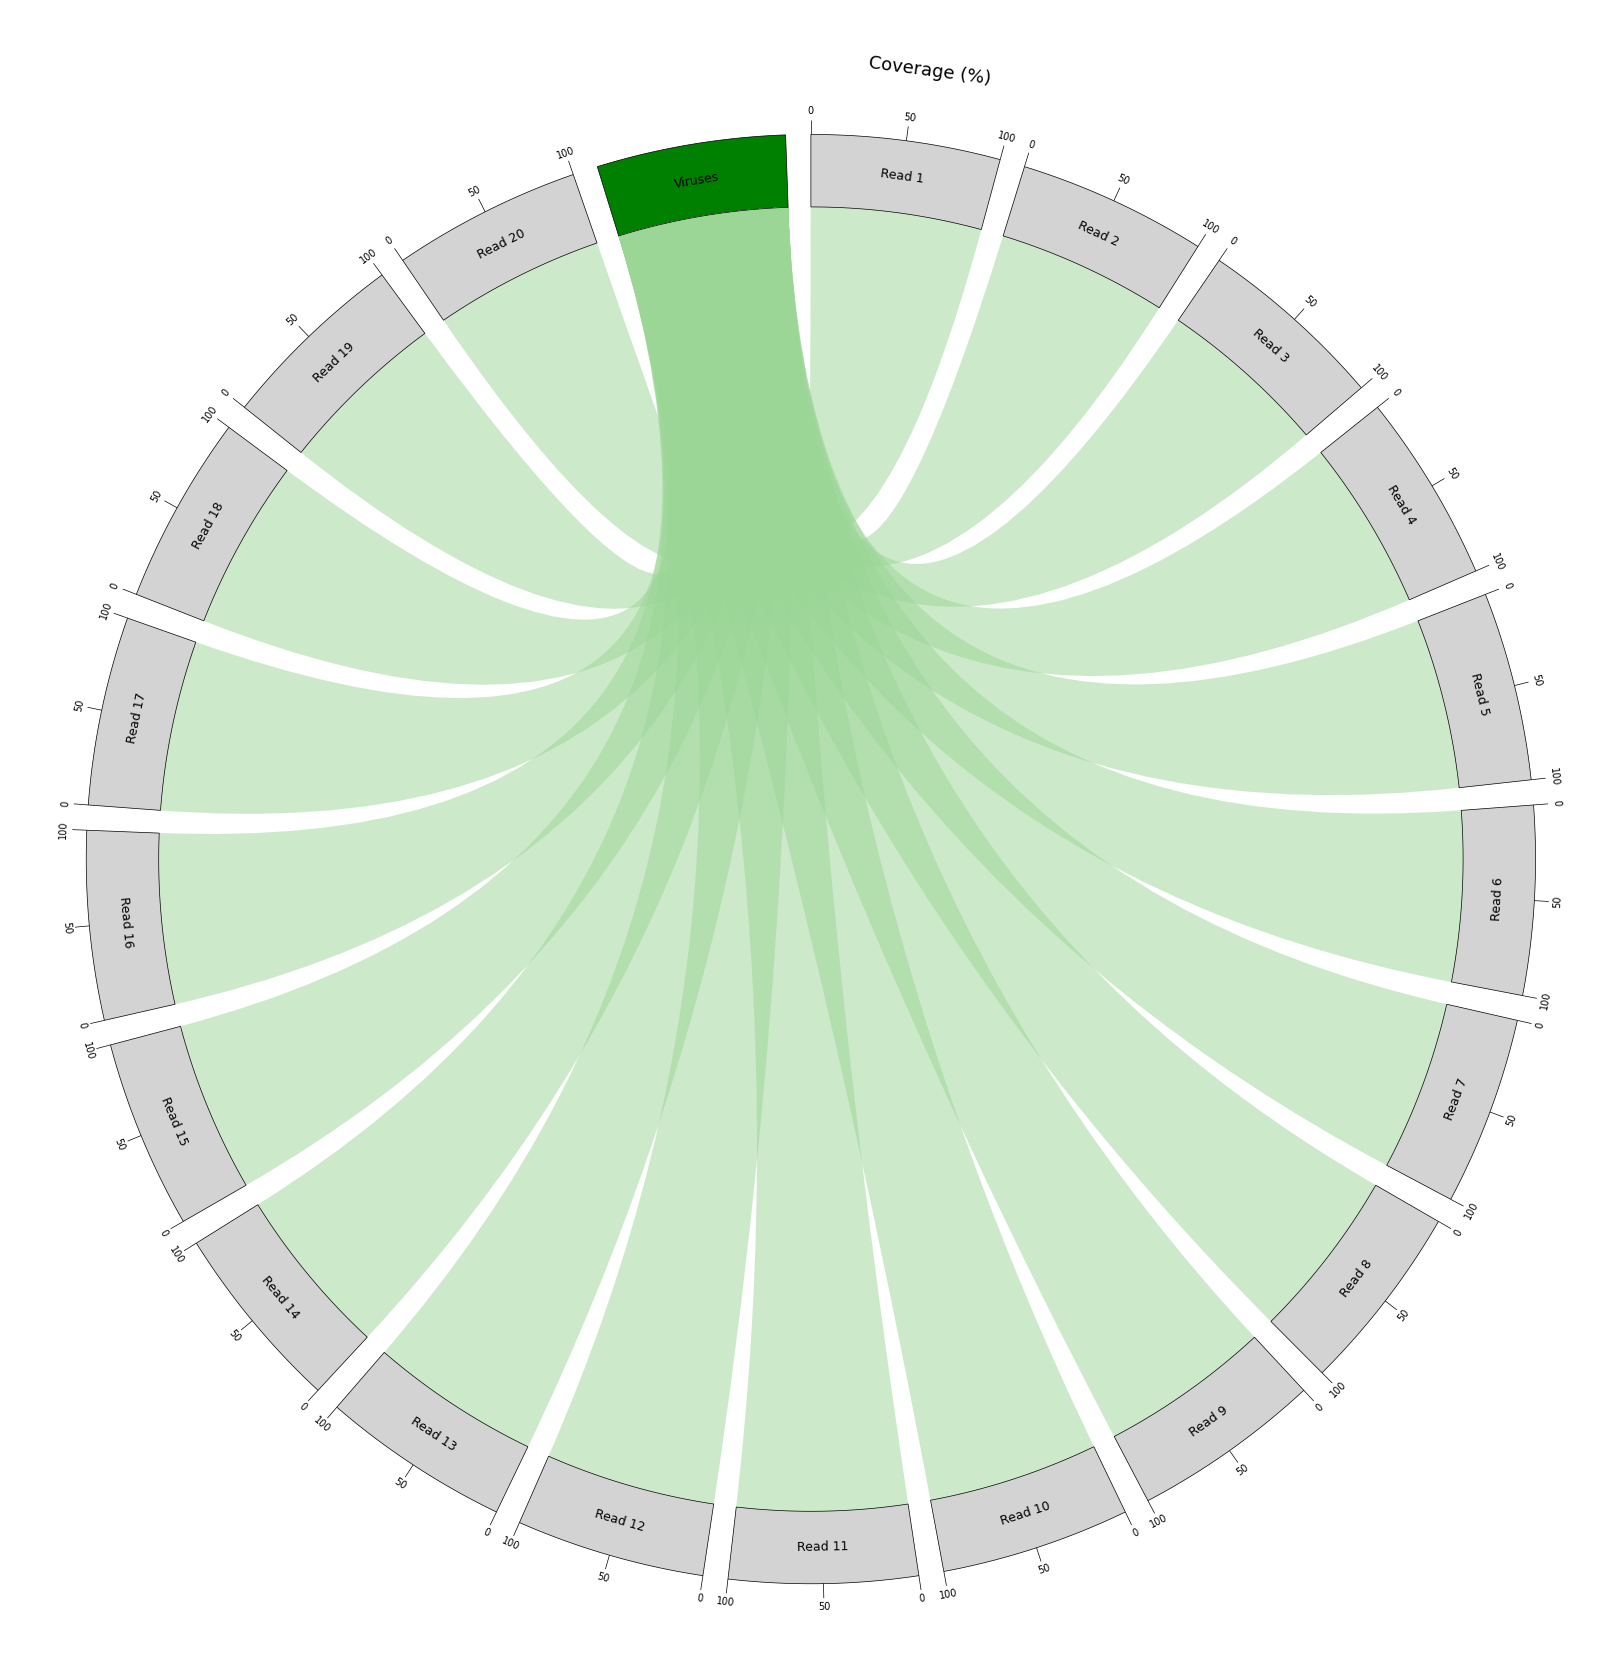

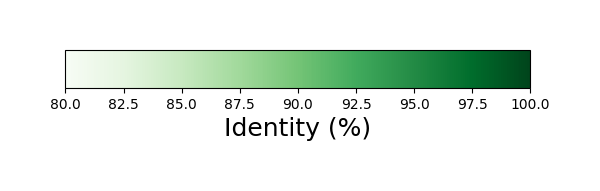

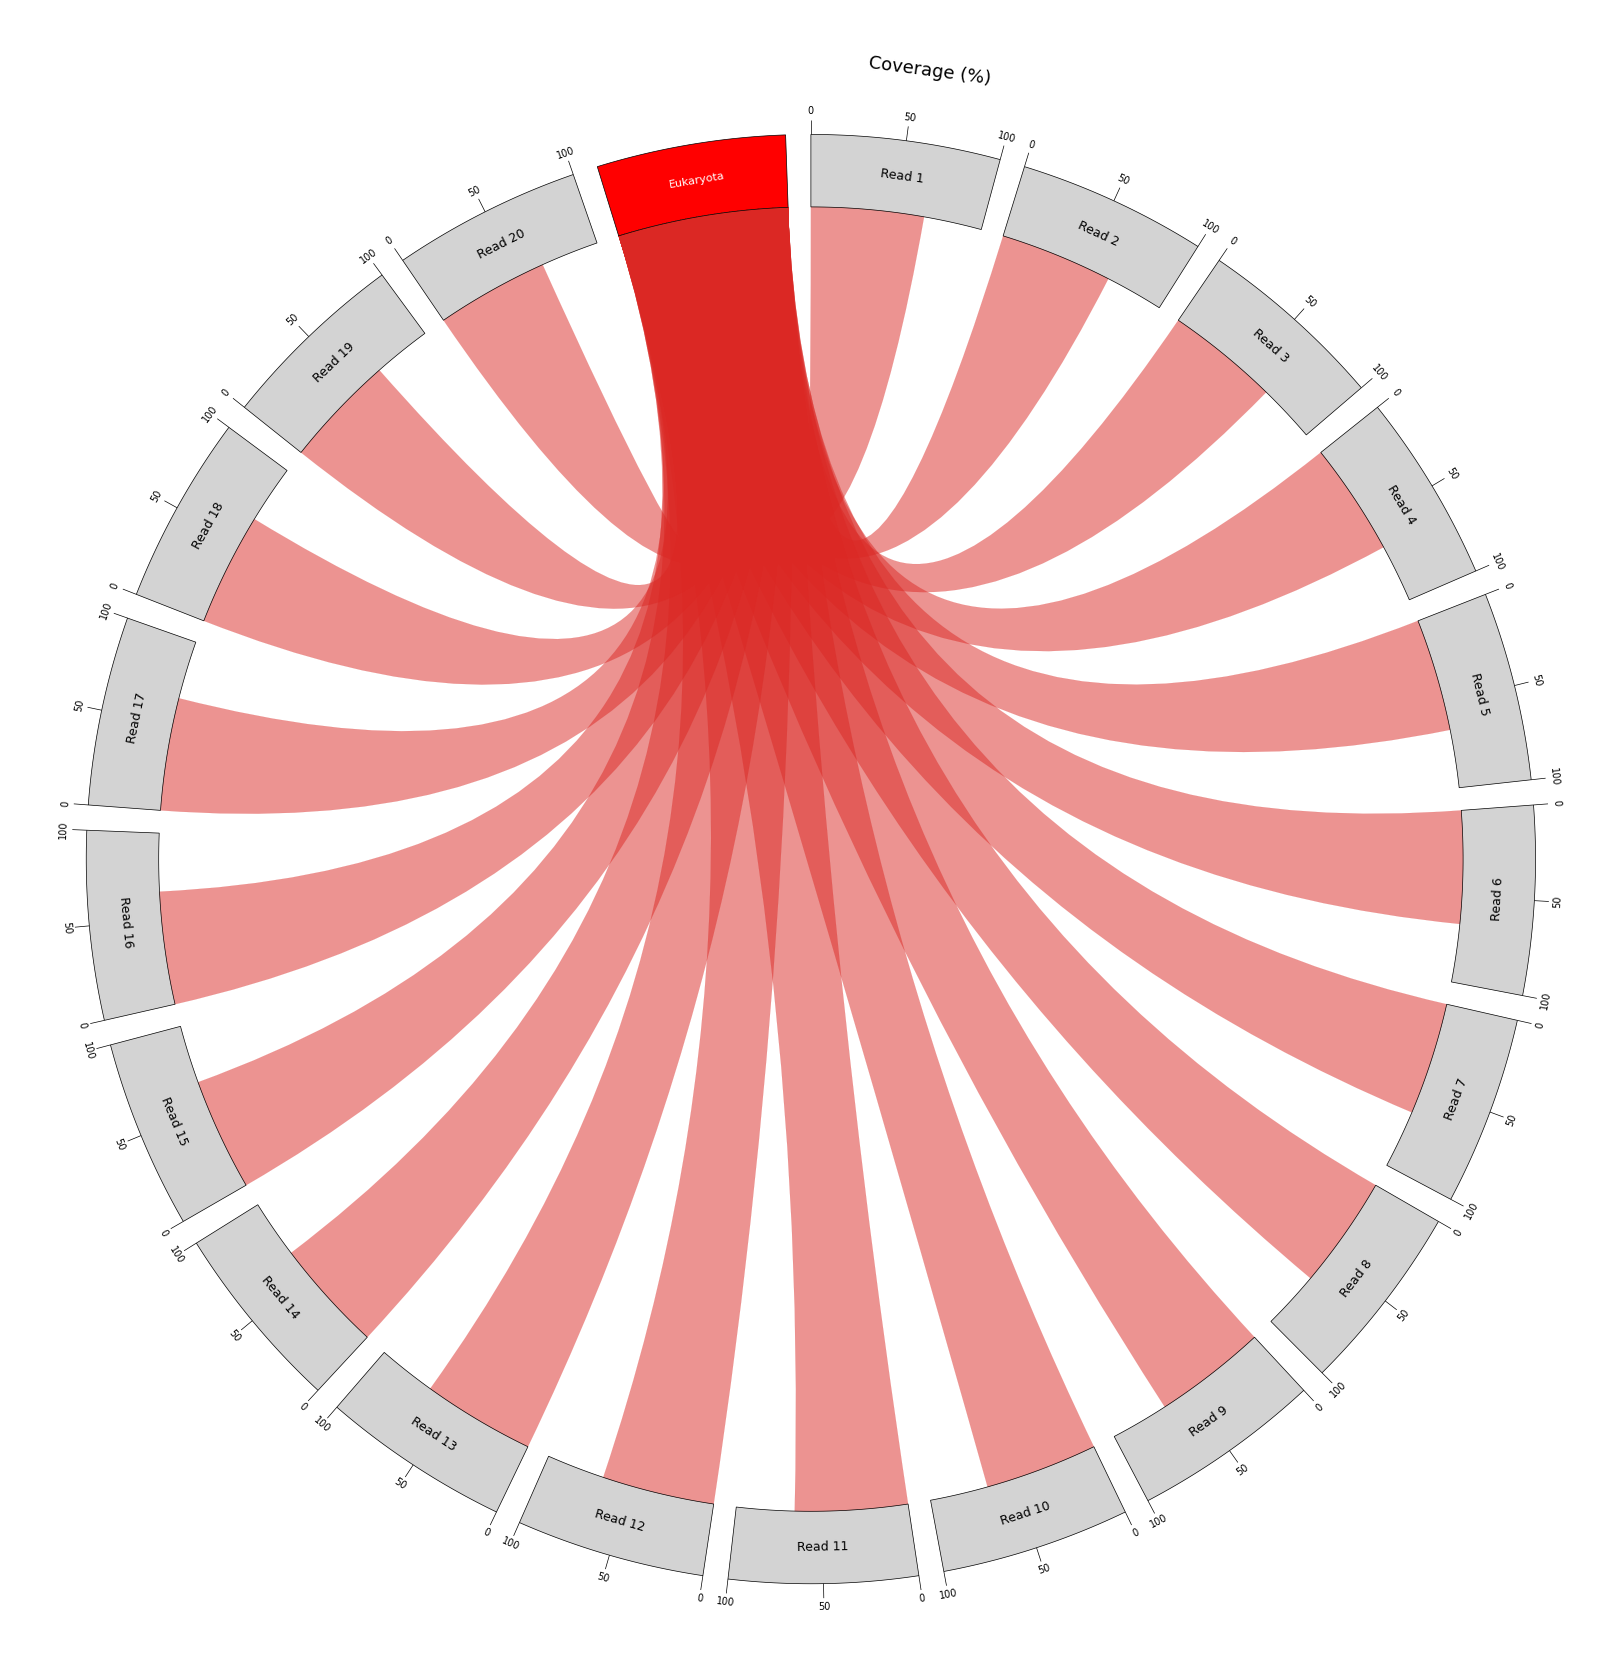

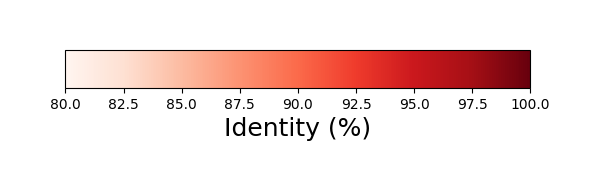

In [59]:
for vir in virs_to_blast:
    x = 0
    for tax in ['Bacteria', 'Viruses', 'Eukaryota']:
        panel = ['a', 'b', 'c']
        plot_blast_results(final_df, vir, tax_level="Subject Super Kingdom", ref = tax, read_nums=20,
                          save_name = f"figures_final/supp_fig_12{panel[x]}.png")
        x += 1